#  import kit

In [2]:
import sys
from pathlib import Path
ROOT = Path().resolve().parents[1]
sys.path.append(str(ROOT / "src"))

In [3]:
import pickle
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pylatexenc
from PEC_sampler_package_cnot import cnot_PEC_Readout_Module_Sampler as pecro
from PEC_sampler_package_cnot import cnot_PEC_TQG_Module_Sampler as peccx
from PEC_sampler_package_cnot import cnot_PEC_sampler as pec
from PEC_sampler_package_cnot import cnot_Restore_Retrieve as RR
import Cnot_Fault as cxft

import qiskit as q
from qiskit import QuantumCircuit
from qiskit.visualization import *
from qiskit.circuit.library import *
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService

In [4]:
token = "PJubuPXreZKAxan0yV6OLEIkdKipFYGgvvkGQSZAtpMU"
instance = 'crn:v1:bluemix:public:quantum-computing:us-east:a/f071734952cb4c9993a642d0a87d18bb:392306ae-fe55-475c-a8c5-978d0ba1871e::'
name = "torino"
device_name = "ibm_" + name
QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token=token,
        instance=instance,
        set_as_default=True,
        overwrite=True
    )
service = QiskitRuntimeService()
device = service.backend(device_name)
noise_model = NoiseModel.from_backend(device)

In [5]:
backend = AerSimulator.from_backend(device)
backend_options = {
    # "method": "automatic",
    "noise_model": noise_model,
    "basis_gates": noise_model.basis_gates,
    "coupling_map": device.configuration().coupling_map,
    # parallelism knobs
    # "max_parallel_experiments":32,
    # "max_parallel_threads": 0
    # "device": "GPU",  # if you have qiskit-aer-gpu
}
run_options = {
    "shots": 1024,
    # "seed_simulator": 12345,
}

sampler = SamplerV2(
    options={
        "backend_options": backend_options,
        "run_options": run_options,
        # "default_precision": 0.0,  # if you want deterministic path where applicable
    }
)
sampler.mode=backend
backendqubitNum = backend.num_qubits
print(backendqubitNum)

133


# Build Teleportation Circuit

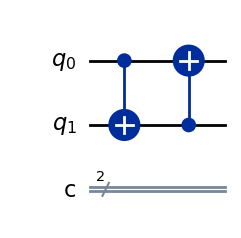

In [6]:
Cnot = QuantumCircuit(2, 2)
# Add Cnot
Cnot.cx(0, 1)
Cnot.cx(1, 0)
Cnot.draw('mpl')

# Calculate Readout PEC Observable

In [ ]:
importlib.reload(pecro)
pec_readout_info = pecro.readout_pec_sampler_subsystem(Cnot, sampler, backend, shots=1024, batch_mode=True, backend_options=backend_options)

In [7]:
# RR.save_readout_result(pec_readout_info, fname="Oweights", parent_dir="ROWeight")
pec_readout_info = RR.load_readout_result("ROWeight/20260228-161303/Oweights.pkl")

In [8]:
B = pec_readout_info["B"]
readout_weights = pec_readout_info["ReadoutWeight"]
print("B:", B, "\nReadoutWeight:", readout_weights)

B: [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.36718750e-02  8.13476562e-01 -6.83593750e-03 -2.05078125e-02
  -3.90625000e-02  2.83203125e-02 -3.22265625e-02  5.56640625e-02
  -1.75781250e-02  3.80859375e-02  2.44140625e-02  6.83593750e-03
  -4.00390625e-02  6.44531250e-02  3.90625000e-03 -7.81250000e-03]
 [ 1.56250000e-02 -3.90625000e-03  8.07617188e-01 -2.53906250e-02
  -3.12500000e-02  8.98437500e-02 -2.05078125e-02  2.53906250e-02
  -2.34375000e-02  3.90625000e-03  3.22265625e-02  2.14843750e-02
  -1.36718750e-02 -1.36718750e-02  4.00390625e-02  0.00000000e+00]
 [ 5.37109375e-03 -2.49023438e-02 -4.39453125e-03  8.23730469e-01
  -4.39453125e-03 -1.46484375e-03  1.51367188e-02 -1.61132812e-02
  -1.46484375e-03  4.44335938e-02  3.17382812e-02 -4.24804688e-02
   4

# Calculate CNOT PEC Weight

In [ ]:
importlib.reload(peccx)
pack = peccx.compute_tqg_matrices(sampler, Cnot, shots=1024, obs_batch=1024)

In [ ]:
pec_tqg_info = peccx.averaged_pauli_twirling_matrix(pack, B=pec_readout_info["B"])
tqg_weights = peccx.compute_inv_weights_for_package(pec_tqg_info)
tqg_weights

In [ ]:
RR.save_vectors(tqg_weights, fname="Gweights", parent_dir="TQGWeight")

In [9]:
load_weights = RR.load_vectors("TQGWeight/20260228-161303/Gweights.npy")
tqg_weights = load_weights["vectors"]
tqg_weights

{(0,
  1): array([ 7.51914303e-01,  2.39929628e-01, -6.30118201e-03,  4.43911729e-03,
        -1.89261544e-02,  5.44300243e-04,  2.37056784e-01, -2.58106702e-01,
         1.66542867e-02,  7.50598882e-04, -2.36045391e-01,  2.57487653e-01,
         2.50787017e-01, -2.38143050e-01, -8.54252974e-04, -1.18695674e-03]),
 (1,
  0): array([ 0.74623454, -0.01070276,  0.00600089,  0.24126911,  0.24774924,
        -0.00441377,  0.00568401, -0.23821494, -0.00765338,  0.23765373,
        -0.24374741,  0.0034803 ,  0.01224265, -0.26179097,  0.2618799 ,
         0.00432887])}

In [28]:
importlib.reload(pec)
importlib.reload(cxft)
importlib.reload(RR)

<module 'PEC_sampler_package_cnot.cnot_Restore_Retrieve' from '/home/n96134289/PEC/src/PEC_sampler_package_cnot/cnot_Restore_Retrieve.py'>

In [11]:
def create_cnot_circuit(n:int):
    circuits = []
    for k in range(1, n + 1):
        qc = QuantumCircuit(2, 2)
        for i in range(k):
            if i % 2 == 0:
                qc.cx(0, 1)  # 正: 0 -> 1
            else:
                qc.cx(1, 0)  # 反: 1 -> 0
        circuits.append(qc)
    return circuits

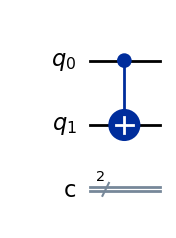

In [12]:
cnot_cir = create_cnot_circuit(4)
cnot_cir[0].draw('mpl')

In [25]:
pauli_labels = cxft.pauli_labels_k(2) 
observables = {f"meas{lbl}": cxft.obs(lbl) for lbl in pauli_labels}
def cal_expectation(res, pl_labels, readout_weights):
    m = cxft.meas_dict_to_vec(res, pl_labels)
    return cxft.expect_from_weights(readout_weights, "ZZ", m)

In [21]:
import json
import numpy as np
from pathlib import Path
from datetime import datetime

# ====== 設定輸出資料夾與檔名 ======
tag = datetime.now().strftime("%Y%m%d-%H%M%S")
out_dir = Path("outputs") / f"{tag}"
out_dir.mkdir(parents=True, exist_ok=True)

def _save_checkpoint(expectation_set: dict, json_path):
    # JSON：好讀、可追蹤
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(expectation_set, f, ensure_ascii=False, indent=2)

In [31]:
inner_json_path = out_dir / "checkpoint.json"
outer_json_path = out_dir / "expectation_set.json"
expectation_set = {}
for i, cir in enumerate(cnot_cir):
    if i == 3:
        plan = cxft.prepare_tqg_pec_plan(qcircuit=cir, tqg_weights=tqg_weights)
        expect = []
        for j in range (6):
            res = pec.run_tqg_pec_package_sampler(
                                        sampler=sampler,
                                        qcircuit=cir,
                                        observables=observables,            # {'measXX': SparsePauliOp(...), ...}
                                        tqg_weights=tqg_weights,
                                        backend=backend,
                                        opt_level=0,
                                        shots=1024,
                                        num_workers=64,
                                        max_batch=2048,
                                        plan=plan,
                                        verbose=True)
            expect.append(cal_expectation(res, pauli_labels, readout_weights))
            # 每次新增一筆就存一次（checkpoint）
            key = f"{j+1}results"
            expectation = {key: expect.copy()}
            _save_checkpoint(expectation, inner_json_path)
        expectation_set.update({f'{i+1}CNOT':expect})
        _save_checkpoint(expectation_set, outer_json_path)

Segment 1/1: full-set 0..65535 (total 65536)
[Parallel] Using 64 workers to build 65536 combinations...


KeyboardInterrupt: 

In [ ]:
# with open("log/20260318_cx3_trial20.json", "w") as f: json.dump(expectation_set, f, indent=4)
with open("log/expectation_set_20260305-162552.json", "r") as f: expectation_set = json.load(f)
expectation_set

FileNotFoundError: [Errno 2] No such file or directory: 'log/20260318_cx3_trial20.json'

In [17]:
for key, value in expectation_set.items():
    print(f"{key} mean = {np.mean(value):.6f}")

results1 mean = 1.075767
results2 mean = 1.072761
results3 mean = 1.070076
results4 mean = 1.060094
results5 mean = 1.047424
results6 mean = 1.040181
results7 mean = 1.030255
results8 mean = 1.033891
results9 mean = 1.030905
results10 mean = 1.033648
results11 mean = 1.036151
results12 mean = 1.033514
results13 mean = 1.034589
results14 mean = 1.036423
results15 mean = 1.037779
results16 mean = 1.040179
results17 mean = 1.037815
results18 mean = 1.039037
results19 mean = 1.038033
results20 mean = 1.037280


In [ ]:
# 畫圖
plt.figure()
plt.plot(labels, means, marker='o')
plt.xlabel("numbers of CX")
plt.ylabel("Mean Value")
plt.title("Mean of Each Results Group (10trials)")
plt.grid(True)
plt.show()